# Library Comparison Usage (Big Libraries)

This notebook shows how to use the new functions in `iChem.libchem.libcomp_big` to:

- load mixed clustering results
- quantify overlap/diversity/shared-space metrics
- visualize overlap (Venn/UpSet)
- plot pair-specific exclusive/shared molecule counts for 2 selected libraries
- plot all exact membership combinations across multiple libraries
- inspect molecules from shared clusters with source labels

In [1]:
from pprint import pprint
from IPython.display import display

from iChem.libchem.libcomp_big import (
    load_mixed_cluster_results,
    count_and_map_clusters,
    cluster_flag_counts,
    cluster_indices_by_label,
    cluster_indices_for_label,
    compute_library_space_totals,
    compute_cluster_presence_metrics,
    compute_molecule_level_metrics,
    plot_overlap_sets,
    plot_two_library_space,
    plot_multi_library_combination_space,
    visualize_exclusive_clusters,
    visualize_shared_clusters,
)

In [2]:
# Input paths
final_cluster_path = '/home/klopezperez/iChem/scripts/final_cluster_mixed_libs.pkl'
smiles_dirs = {
    'A': '/home/klopezperez/iChem/tests/data/mcule_macrocycles/',
    'B': '/home/klopezperez/iChem/tests/data/mcule_natural_like_products/',
    'C': '/home/klopezperez/iChem/tests/data/mcule_natural_product_derivatives/'
}

# Library labels for plotting
lib_names = ['A', 'B', 'C']

In [3]:
# Load final mixed clustering outputs
final_bfs, final_mol_ids = load_mixed_cluster_results(final_cluster_path)

# Cluster counts and flags
cluster_counts, cluster_flags = count_and_map_clusters(final_mol_ids)
flag_counts = cluster_flag_counts(cluster_flags=cluster_flags)

len(cluster_counts), flag_counts

(3361,
 Counter({'B': 2114,
          'B+C': 557,
          'C': 540,
          'A': 77,
          'A+B': 41,
          'A+B+C': 25,
          'A+C': 7}))

In [4]:
# Totals by library and shared/exclusive partitions
lib_totals, exclusive_totals, shared_totals = compute_library_space_totals(cluster_counts)

# Cluster-level and molecule-level metrics
cluster_metrics = compute_cluster_presence_metrics(cluster_counts, cluster_flags)
molecule_metrics = compute_molecule_level_metrics(
    lib_totals=lib_totals,
    exclusive_totals=exclusive_totals,
    shared_totals=shared_totals,
    cluster_presence_metrics=cluster_metrics,
)

print('lib_totals:')
pprint(lib_totals)
print('\nexclusive_totals:')
pprint(exclusive_totals)
print('\nshared_totals:')
pprint(shared_totals)
print('\ncluster_metrics:')
pprint(cluster_metrics)
print('\nmolecule_metrics:')
pprint(molecule_metrics)

lib_totals:
{'A': 163427, 'B': 178992, 'C': 109173}

exclusive_totals:
{'A': 26129, 'B': 101705, 'C': 36047}

shared_totals:
{'A': 137298, 'B': 77287, 'C': 73126}

cluster_metrics:
{'flag_counts': Counter({'B': 2114,
                         'B+C': 557,
                         'C': 540,
                         'A': 77,
                         'A+B': 41,
                         'A+B+C': 25,
                         'A+C': 7}),
 'pairwise': {'A+B': {'n_shared_clusters': 41,
                      'pct_shared_given_A': 34.74576271186441,
                      'pct_shared_given_B': 1.902552204176334},
              'A+C': {'n_shared_clusters': 7,
                      'pct_shared_given_A': 8.333333333333334,
                      'pct_shared_given_C': 1.2797074954296161},
              'B+C': {'n_shared_clusters': 557,
                      'pct_shared_given_B': 20.85361287907151,
                      'pct_shared_given_C': 50.77484047402005}},
 'per_library': {'A': {'n_clusters_exclusi

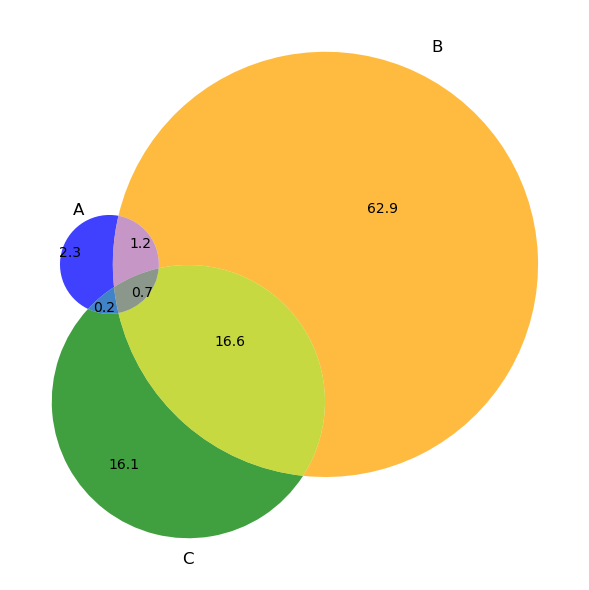

In [5]:
# Overlap visualization
# For 2 libraries this gives a Venn by default.
plot_overlap_sets(flag_counts=flag_counts, lib_names=lib_names, upset=False)

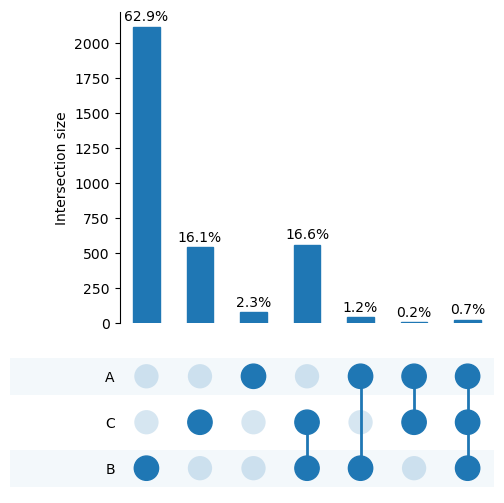

In [6]:
# If you later compare many libraries, UpSet is recommended:
plot_overlap_sets(flag_counts=flag_counts, lib_names=lib_names, upset=True)

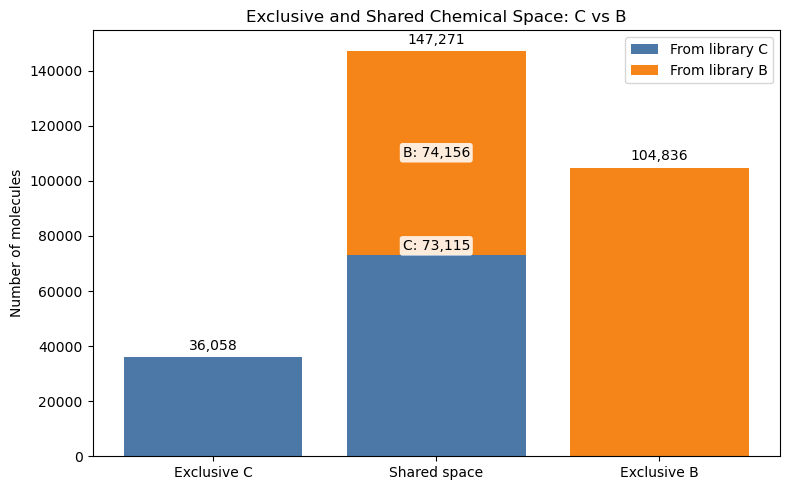

In [14]:
# 2-library molecule-space composition plot (pair-specific, even in 3+ library runs)
plot_two_library_space(
    'C',
    'B',
    cluster_counts=cluster_counts,
    include_multi_combinations=True,
)

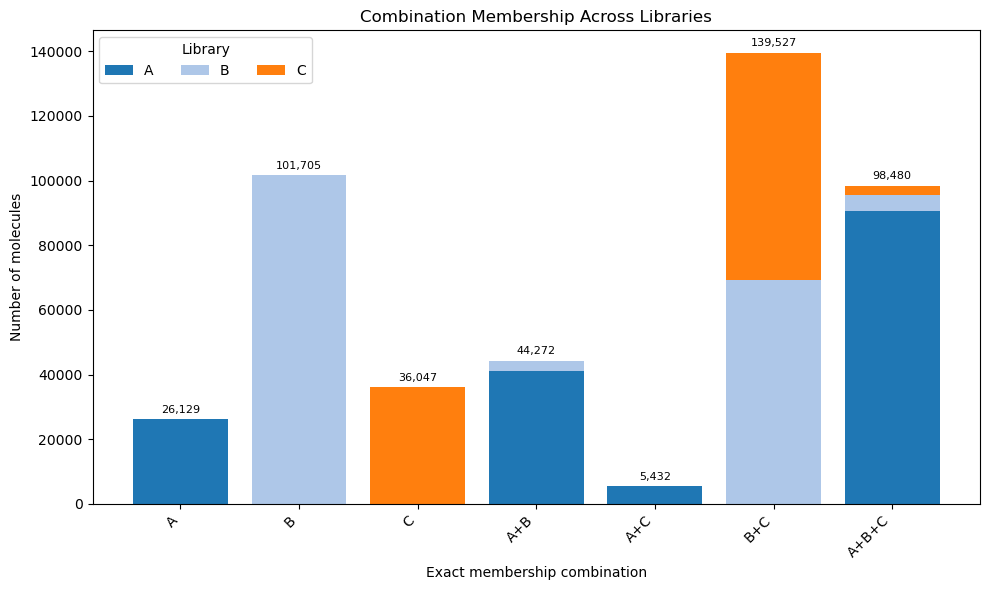

{'combo_labels': ['A', 'B', 'C', 'A+B', 'A+C', 'B+C', 'A+B+C'],
 'combo_totals': [26129, 101705, 36047, 44272, 5432, 139527, 98480]}

In [8]:
# Multi-library combination bar plot (all exact memberships)
combo_summary = plot_multi_library_combination_space(
    cluster_counts=cluster_counts,
    lib_order=lib_names,
    normalize=False,  # set True to view each combination as percentages
 )
combo_summary

Available labels: ['A', 'A+B', 'A+B+C', 'A+C', 'B', 'B+C', 'C']
A exclusive cluster ids: [5, 6, 51, 78, 91, 92, 104, 114, 127, 145, 146, 155, 180, 190, 200, 231, 255, 304, 325, 329, 350, 373, 375, 428, 599, 769, 788, 923, 1020, 1090, 1179, 1369, 1492, 1786, 1787, 1885, 1927, 1942, 1949, 2047, 2062, 2097, 2115, 2229, 2300, 2337, 2454, 2549, 2559, 2602, 2811, 2827, 2918, 2922, 2982, 3010, 3019, 3028, 3046, 3075, 3125, 3142, 3146, 3147, 3148, 3160, 3182, 3216, 3223, 3242, 3244, 3284, 3285, 3287, 3289, 3322, 3329]
B exclusive cluster ids: [11, 23, 28, 32, 36, 40, 47, 49, 54, 55, 57, 62, 64, 72, 86, 94, 102, 108, 111, 116, 117, 124, 131, 132, 135, 136, 137, 138, 139, 140, 150, 154, 156, 160, 162, 163, 164, 167, 169, 172, 176, 181, 183, 186, 187, 194, 197, 201, 203, 205, 206, 207, 208, 210, 211, 212, 213, 215, 226, 227, 228, 229, 230, 233, 237, 238, 241, 243, 244, 245, 246, 247, 249, 252, 253, 258, 259, 260, 262, 263, 264, 267, 270, 276, 282, 287, 288, 289, 290, 292, 295, 296, 297, 298, 300,

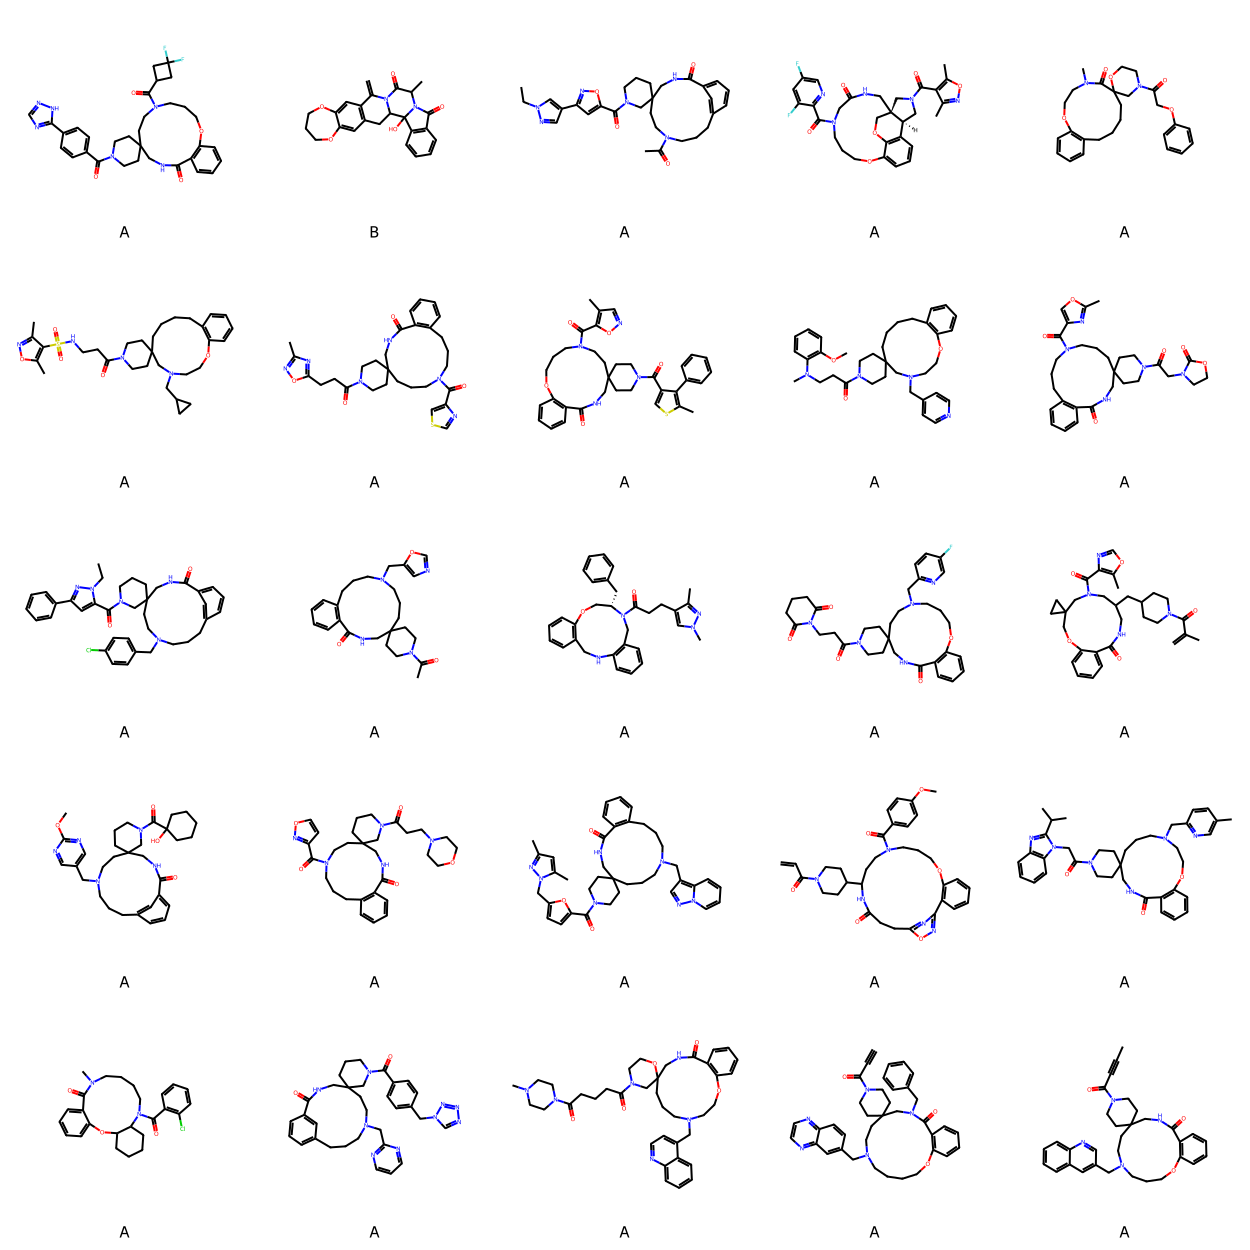

Cluster index: 41 | flag: A+B
Counts: {'A': 1704, 'B': 5}


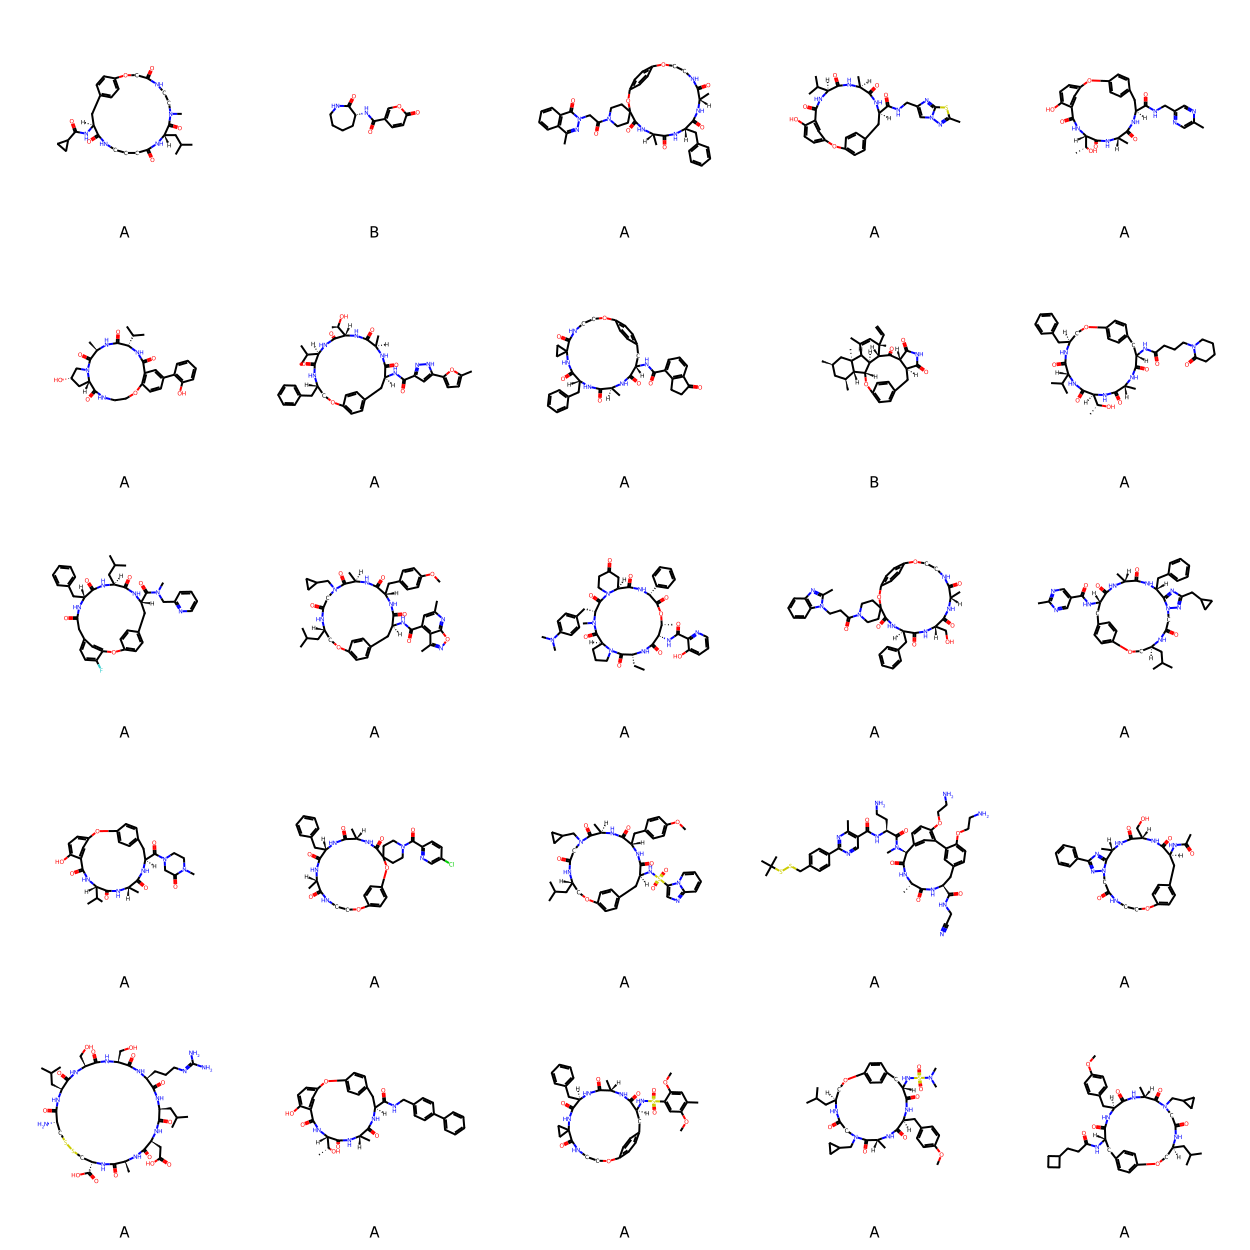

Cluster index: 44 | flag: A+B
Counts: {'A': 1616, 'B': 35}


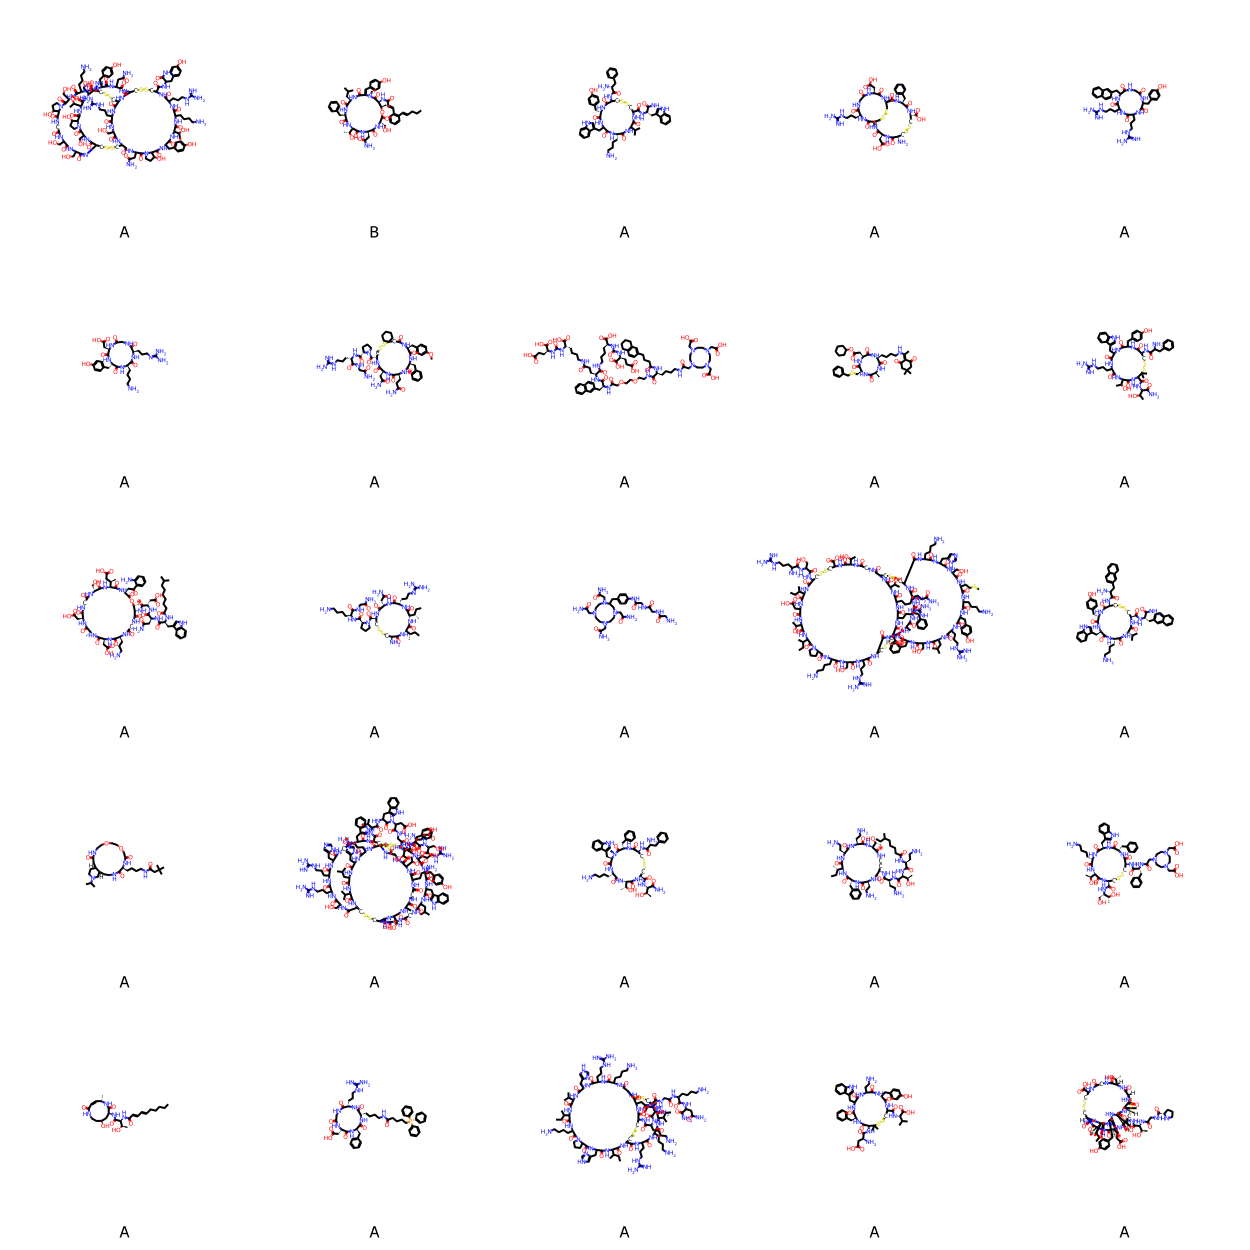

Cluster index: 58 | flag: A+B
Counts: {'A': 5, 'B': 1319}


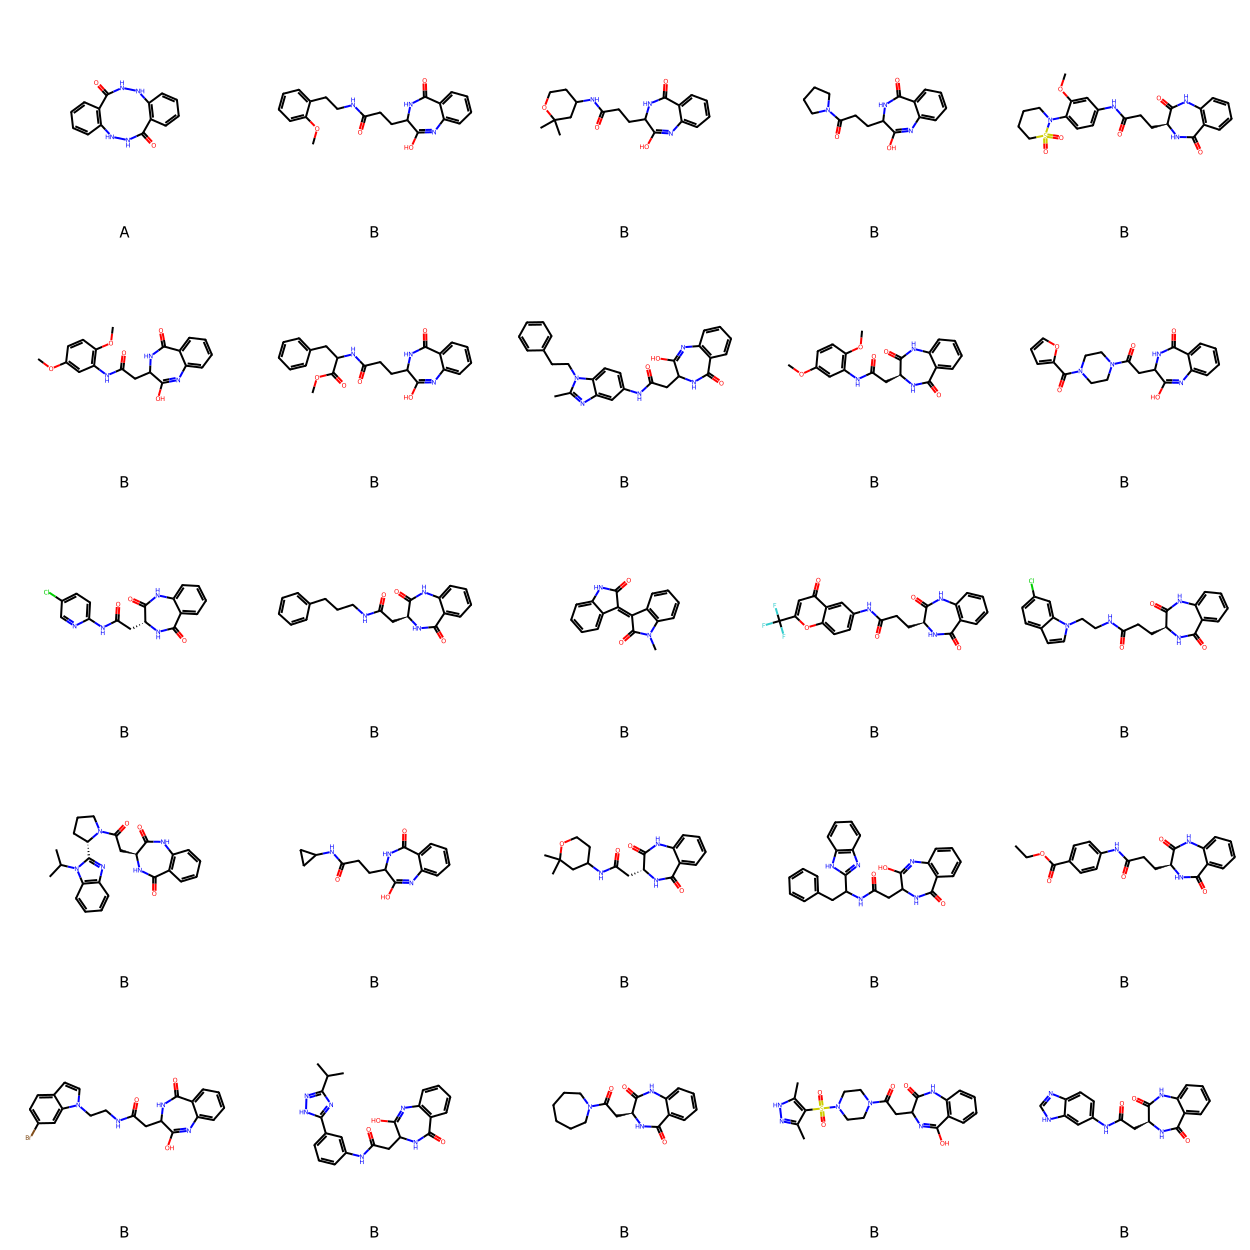

Cluster index: 68 | flag: A+B
Counts: {'A': 1169, 'B': 1}


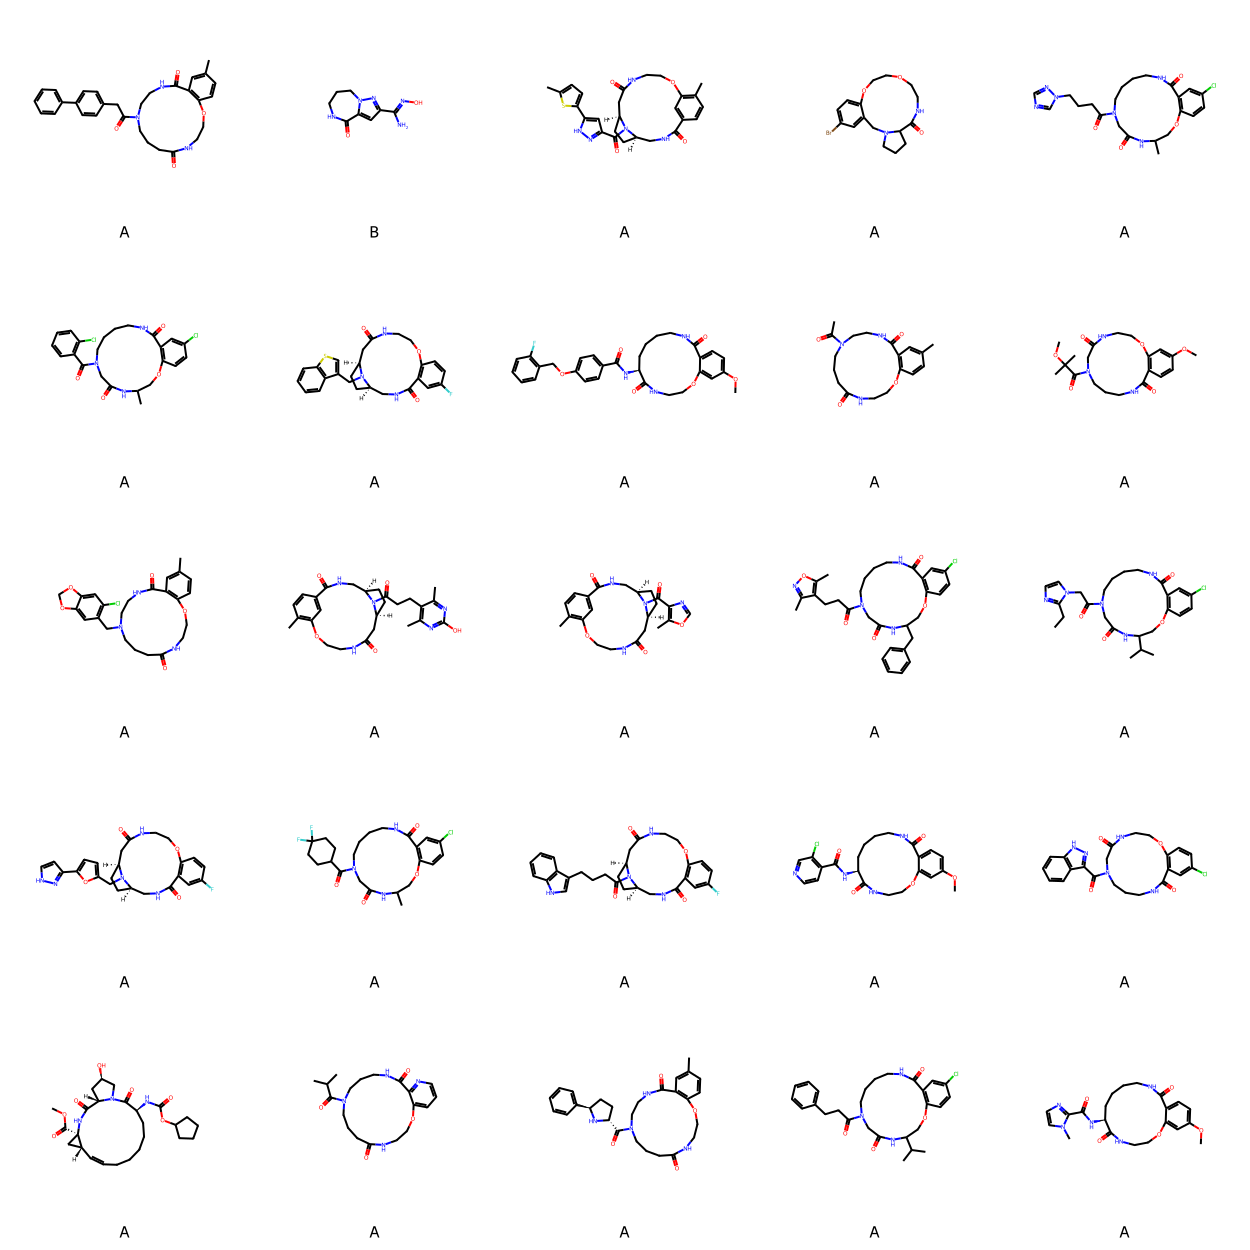

Cluster index: 70 | flag: A+B
Counts: {'A': 1122, 'B': 20}


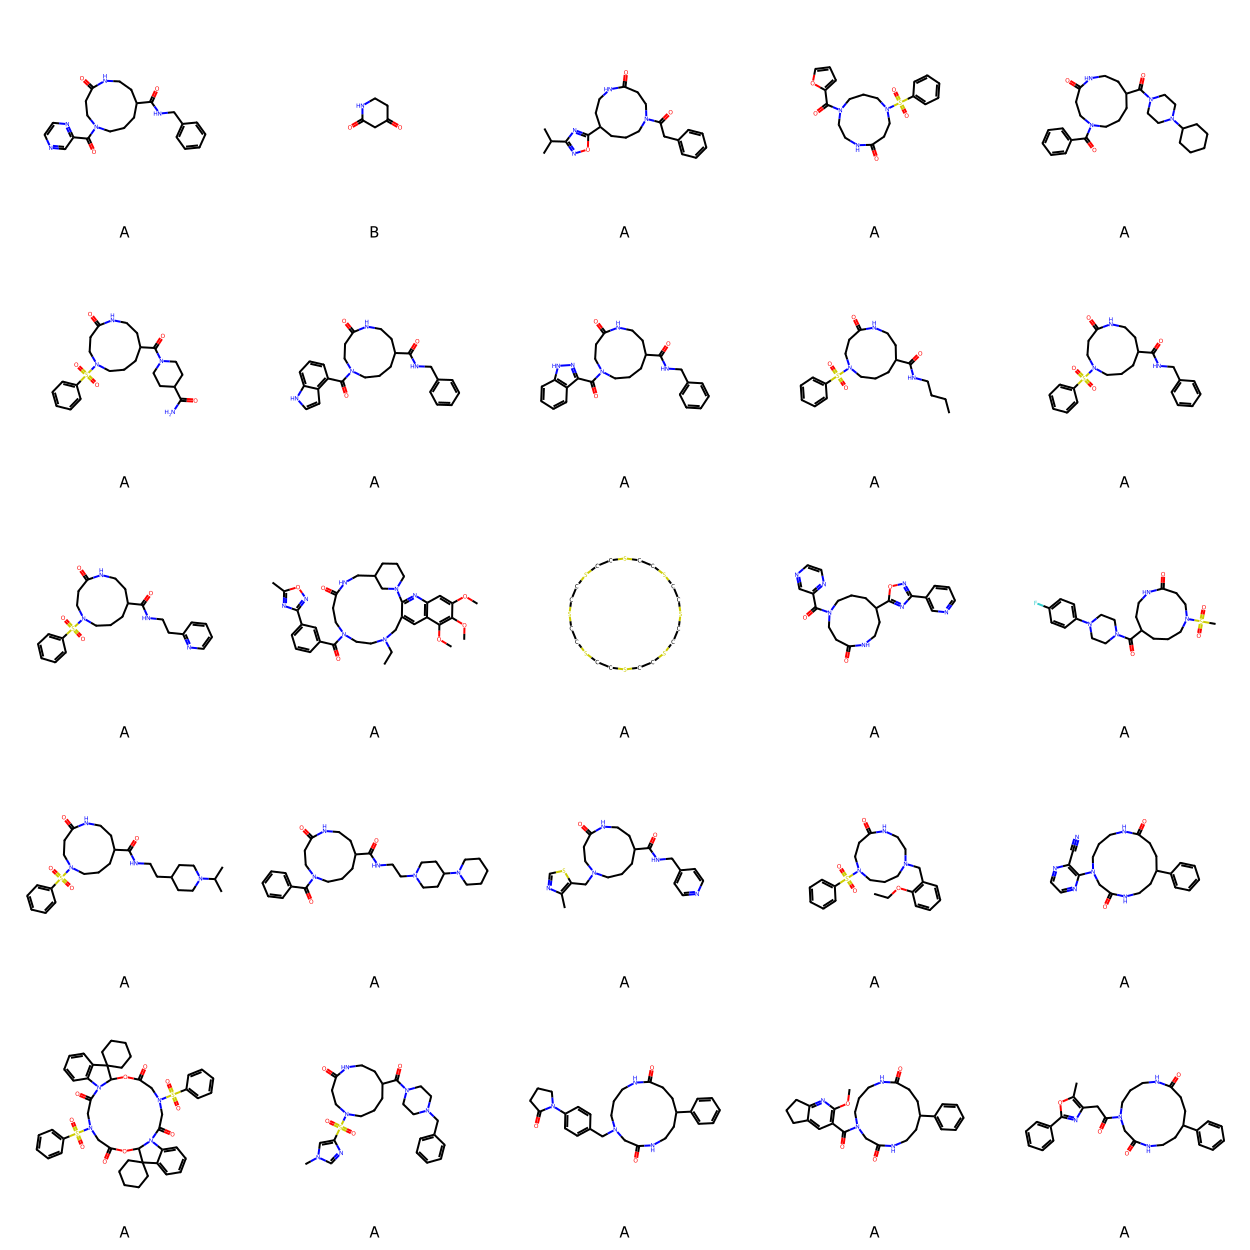

Cluster index: 79 | flag: A+B
Counts: {'A': 1052, 'B': 13}


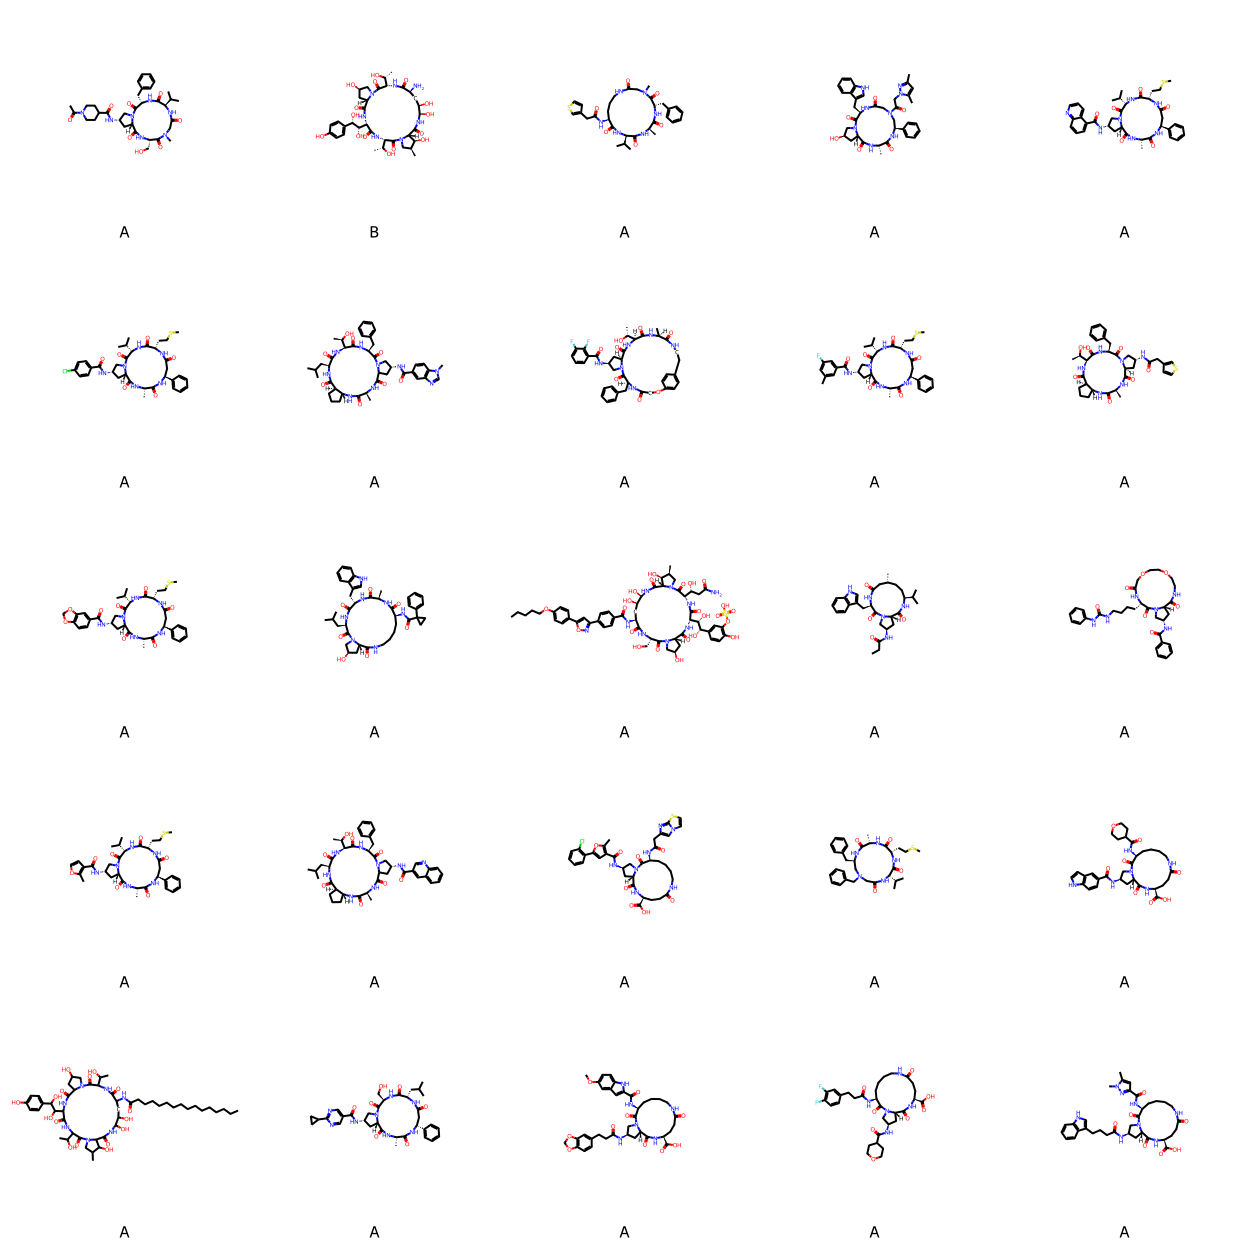

Cluster index: 84 | flag: A+B
Counts: {'A': 992, 'B': 3}


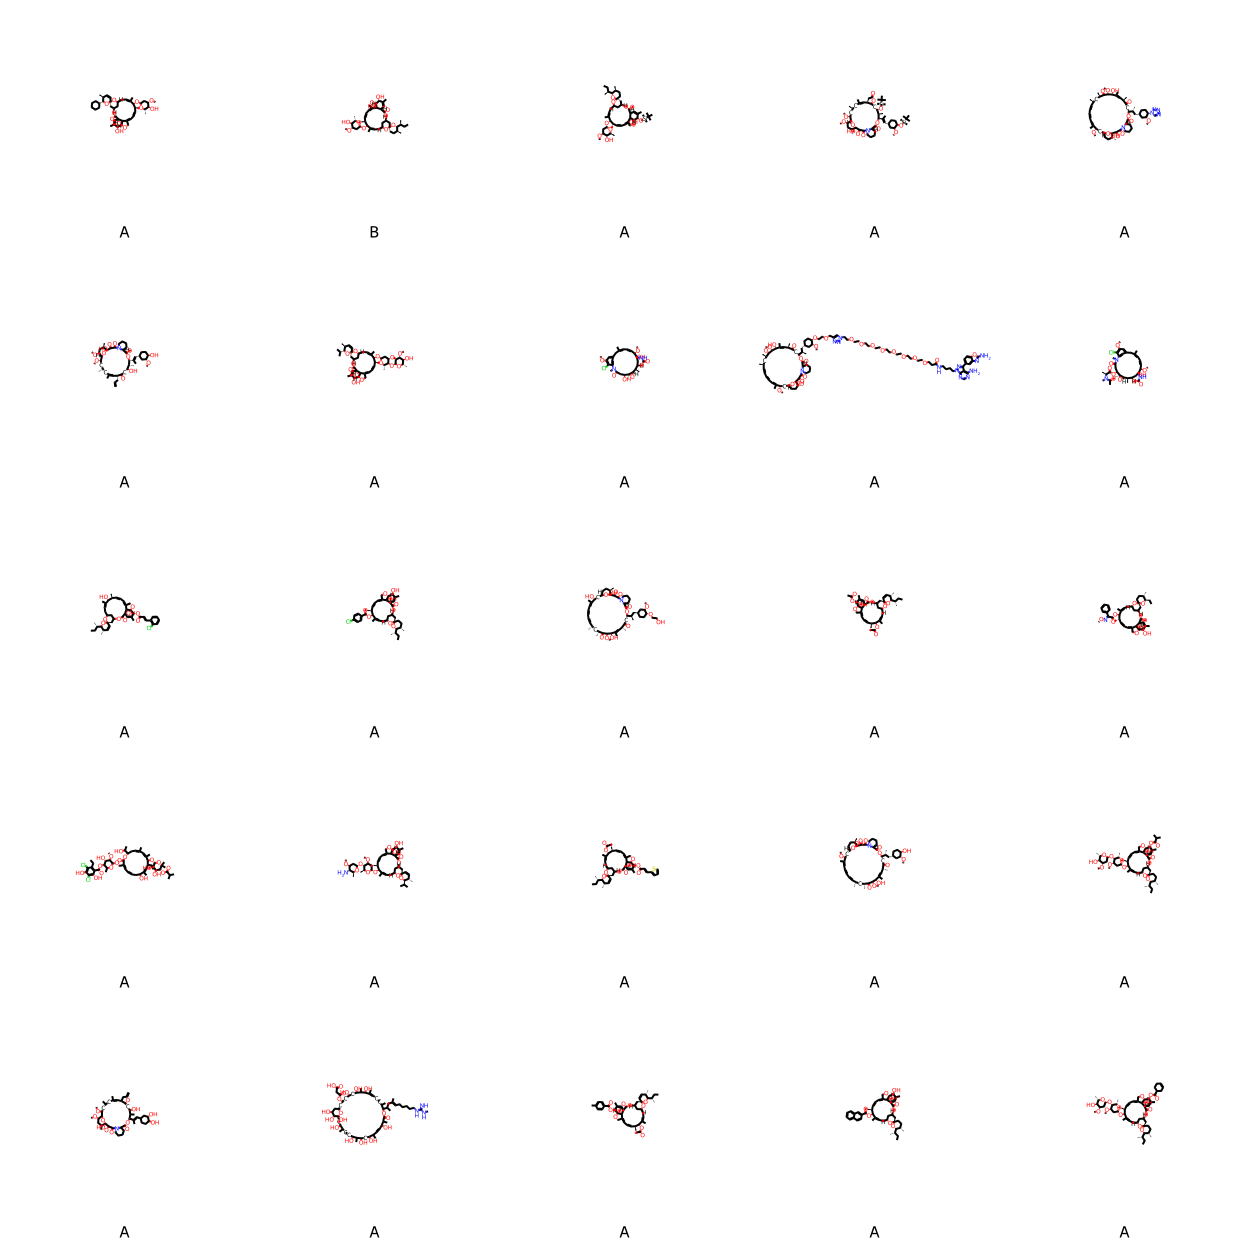

Cluster index: 144 | flag: A+B
Counts: {'A': 547, 'B': 4}


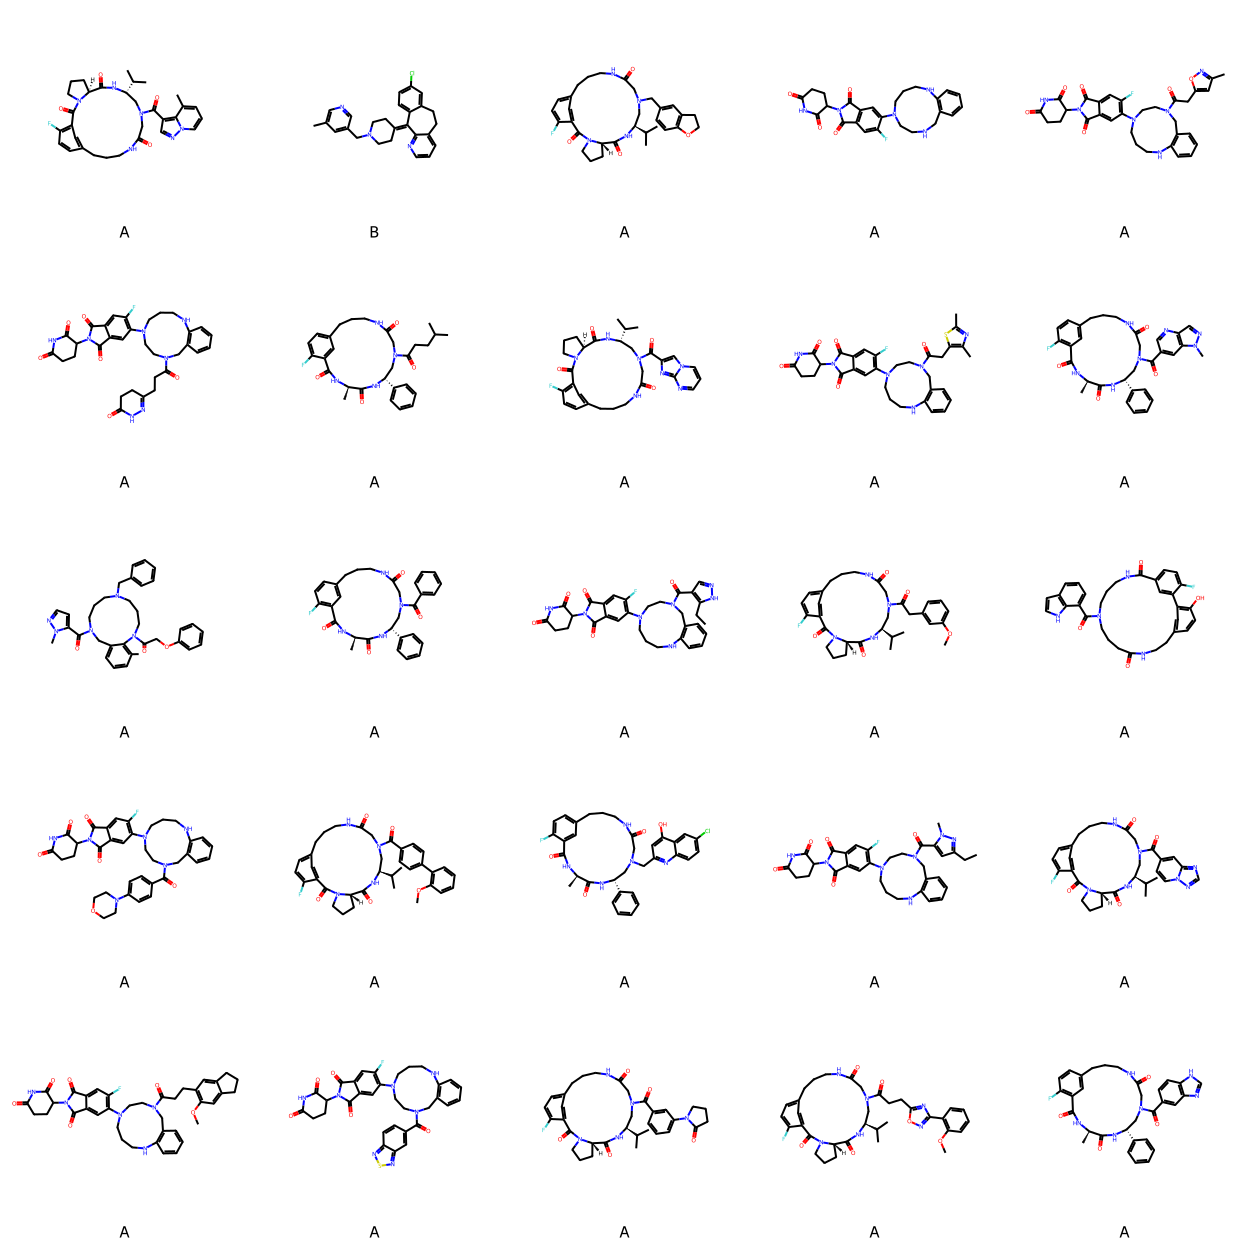

Cluster index: 148 | flag: A+B
Counts: {'A': 4, 'B': 537}


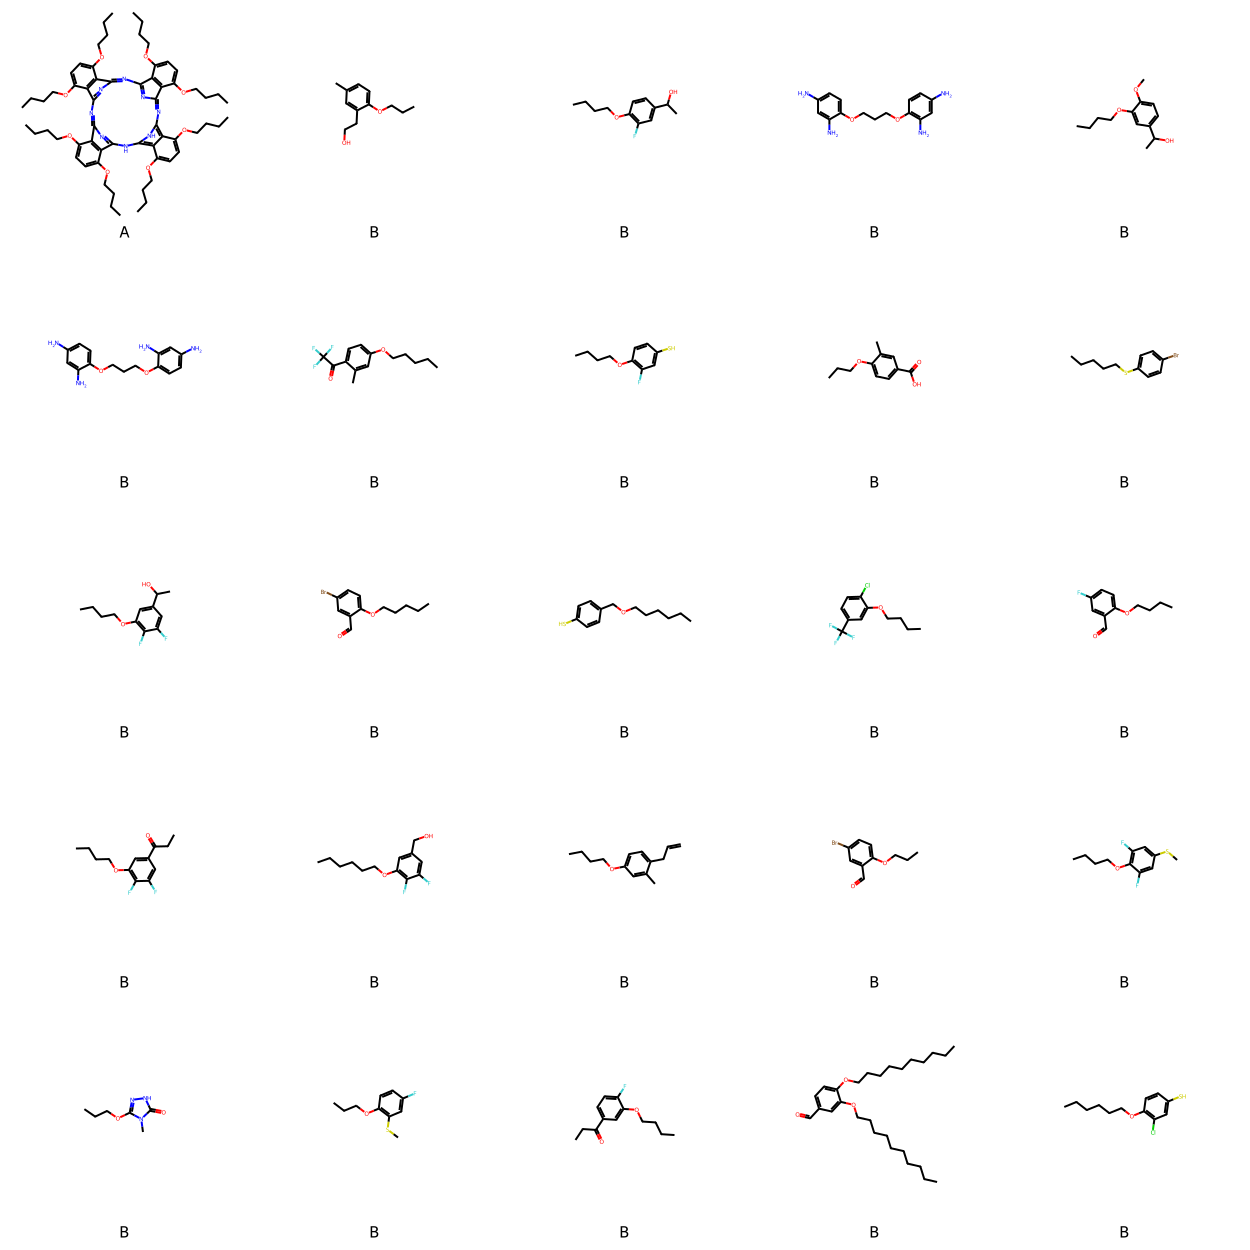

In [9]:
# Cluster ids by label
clusters_by_label = cluster_indices_by_label(cluster_flags=cluster_flags)
print('Available labels:', sorted(clusters_by_label.keys()))
print('A exclusive cluster ids:', cluster_indices_for_label('A', cluster_flags=cluster_flags))
print('B exclusive cluster ids:', cluster_indices_for_label('B', cluster_flags=cluster_flags))
print('A+B shared cluster ids:', cluster_indices_for_label('A+B', cluster_flags=cluster_flags))

# Visualize shared clusters while forcing both libraries to appear in the sampled image
shared_cluster_ids = cluster_indices_for_label('A+B', cluster_flags=cluster_flags)
shared_cluster_views = visualize_shared_clusters(
    final_mol_ids=final_mol_ids,
    smiles_dirs=smiles_dirs,
    n_clusters=3,
    max_mols_per_cluster=25,
    cluster_indices=shared_cluster_ids[:10],
    required_labels=['A', 'B'],
)

for entry in shared_cluster_views:
    print(f"Cluster index: {entry['cluster_index']} | flag: {entry['flag']}")
    print(f"Counts: {dict(entry['counts'])}")
    display(entry['image'])


Exclusive A cluster index: 5 | flag: A
Counts: {'A': 7376}


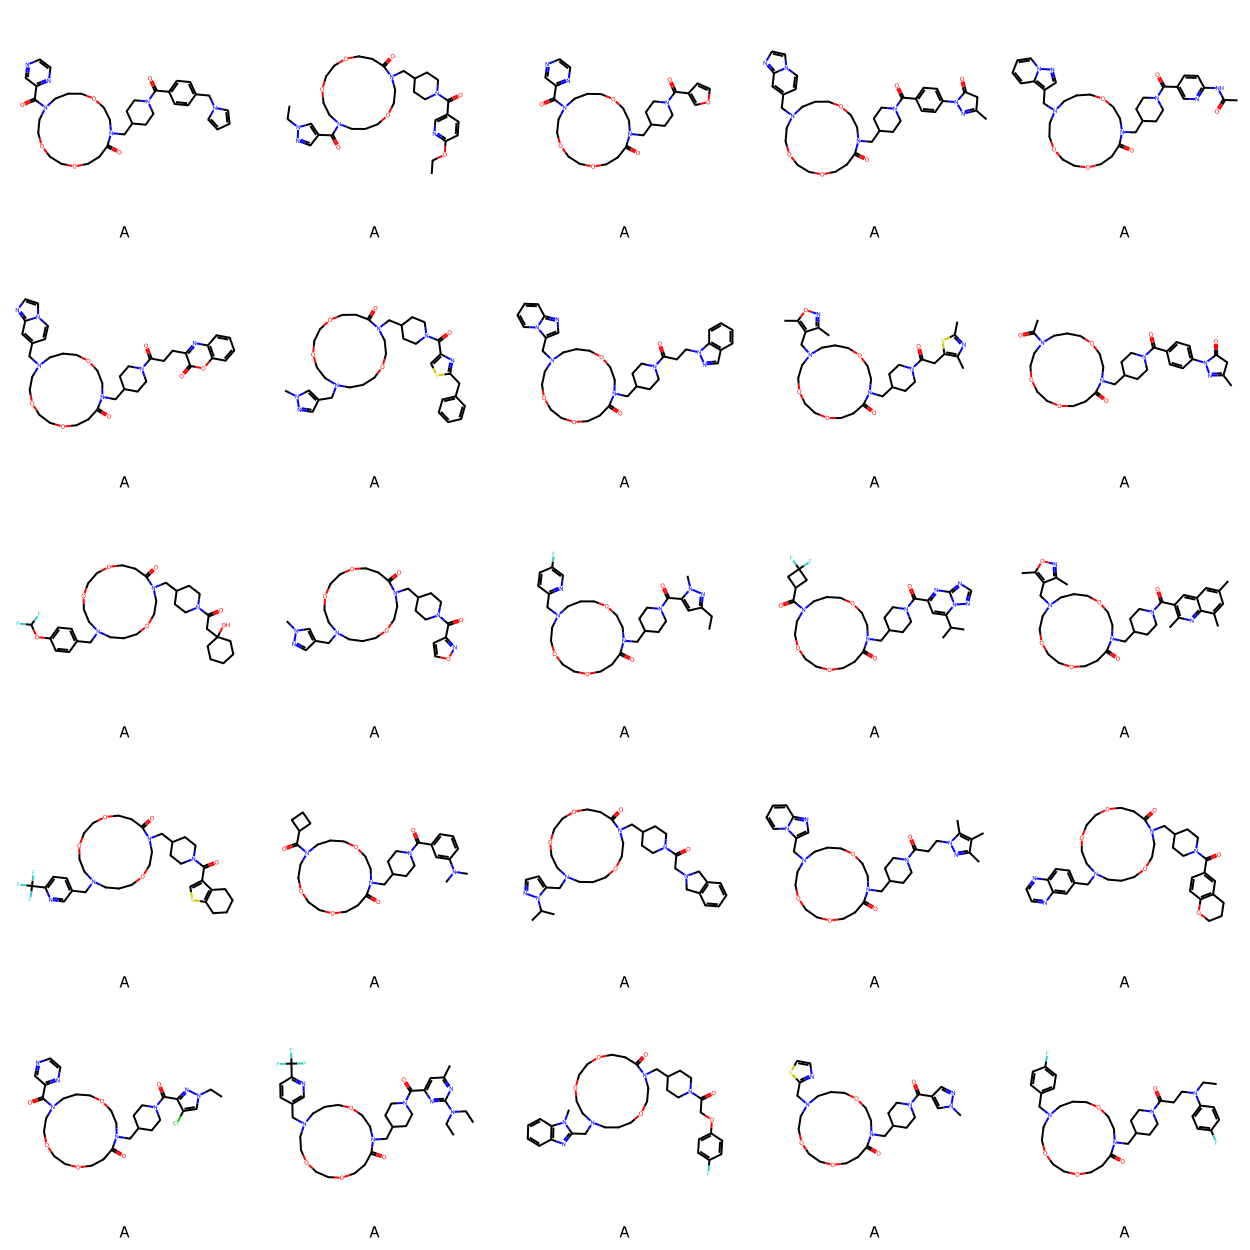

Exclusive A cluster index: 6 | flag: A
Counts: {'A': 7120}


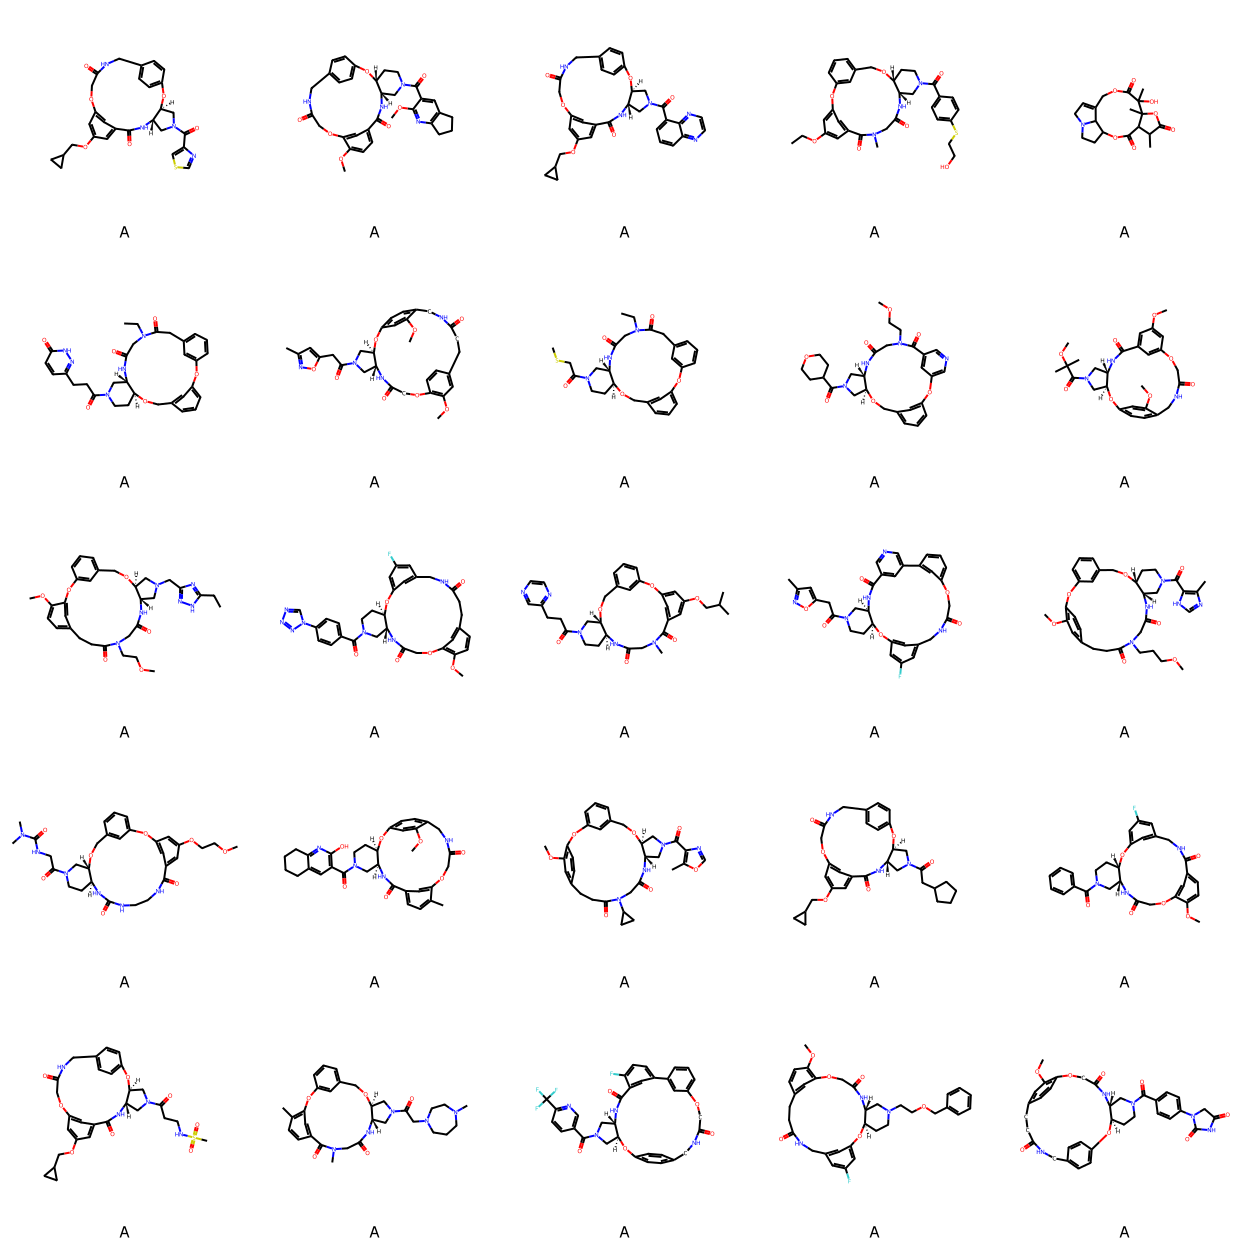

In [10]:
# Visualize exclusive clusters
exclusive_a_views = visualize_exclusive_clusters(
    final_mol_ids=final_mol_ids,
    smiles_dirs=smiles_dirs,
    label='A',
    n_clusters=2,
    max_mols_per_cluster=25,
    cluster_indices=cluster_indices_for_label('A', cluster_flags=cluster_flags)[:2],
)

for entry in exclusive_a_views:
    print(f"Exclusive A cluster index: {entry['cluster_index']} | flag: {entry['flag']}")
    print(f"Counts: {dict(entry['counts'])}")
    display(entry['image'])

Exclusive B cluster index: 11 | flag: B
Counts: {'B': 4209}


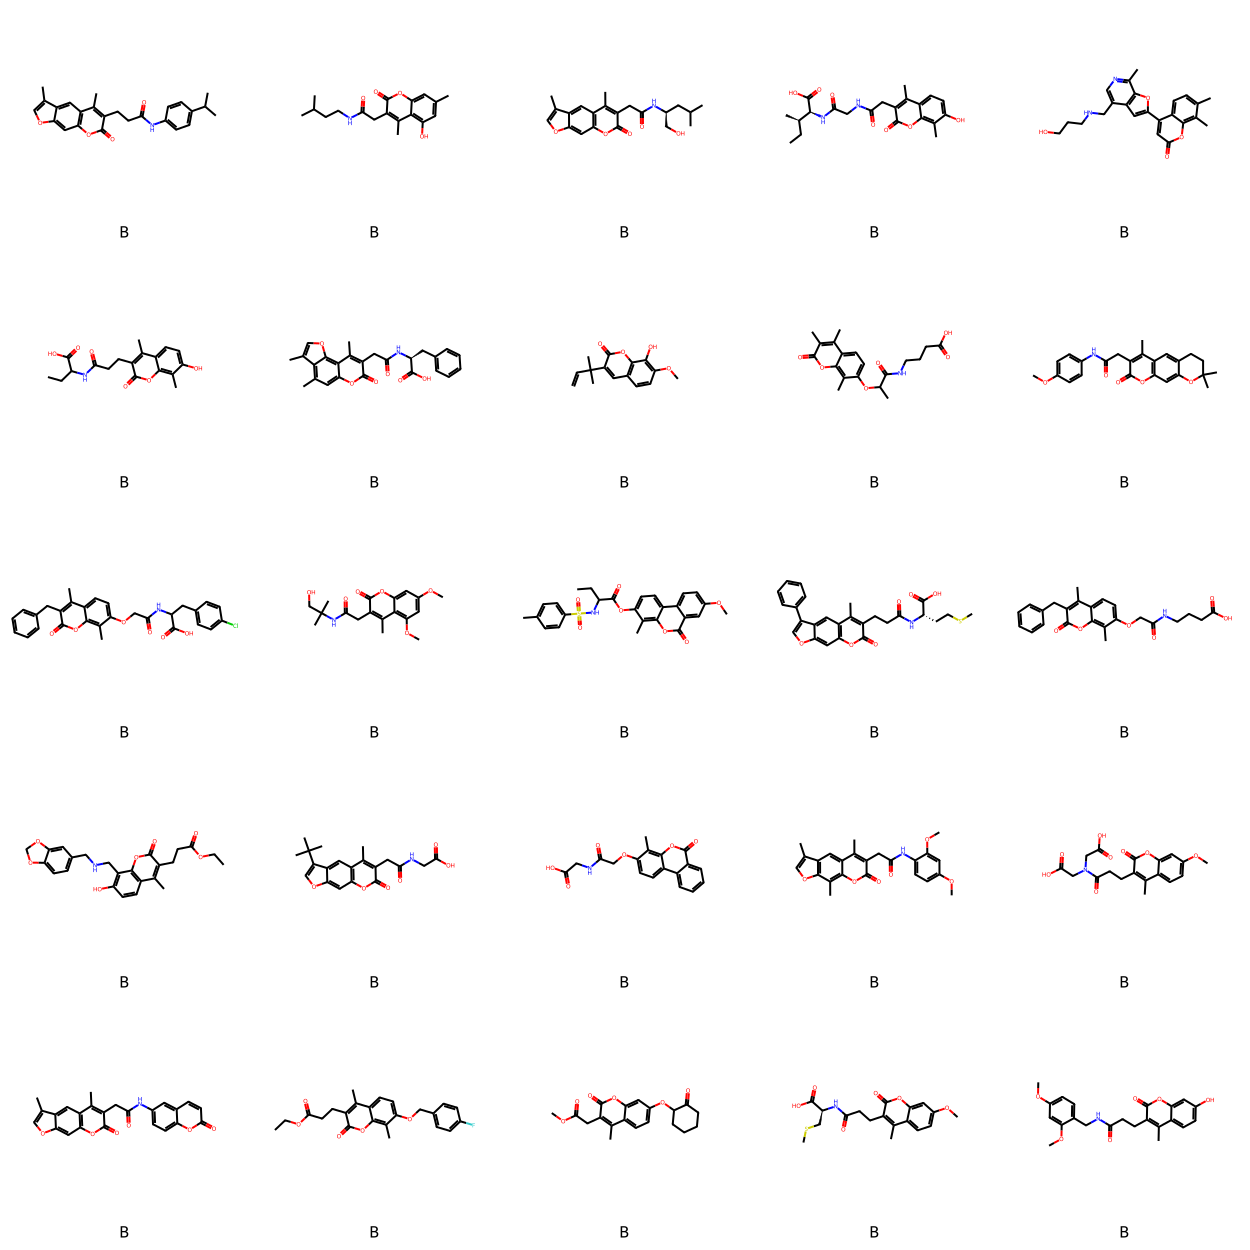

Exclusive B cluster index: 23 | flag: B
Counts: {'B': 2649}


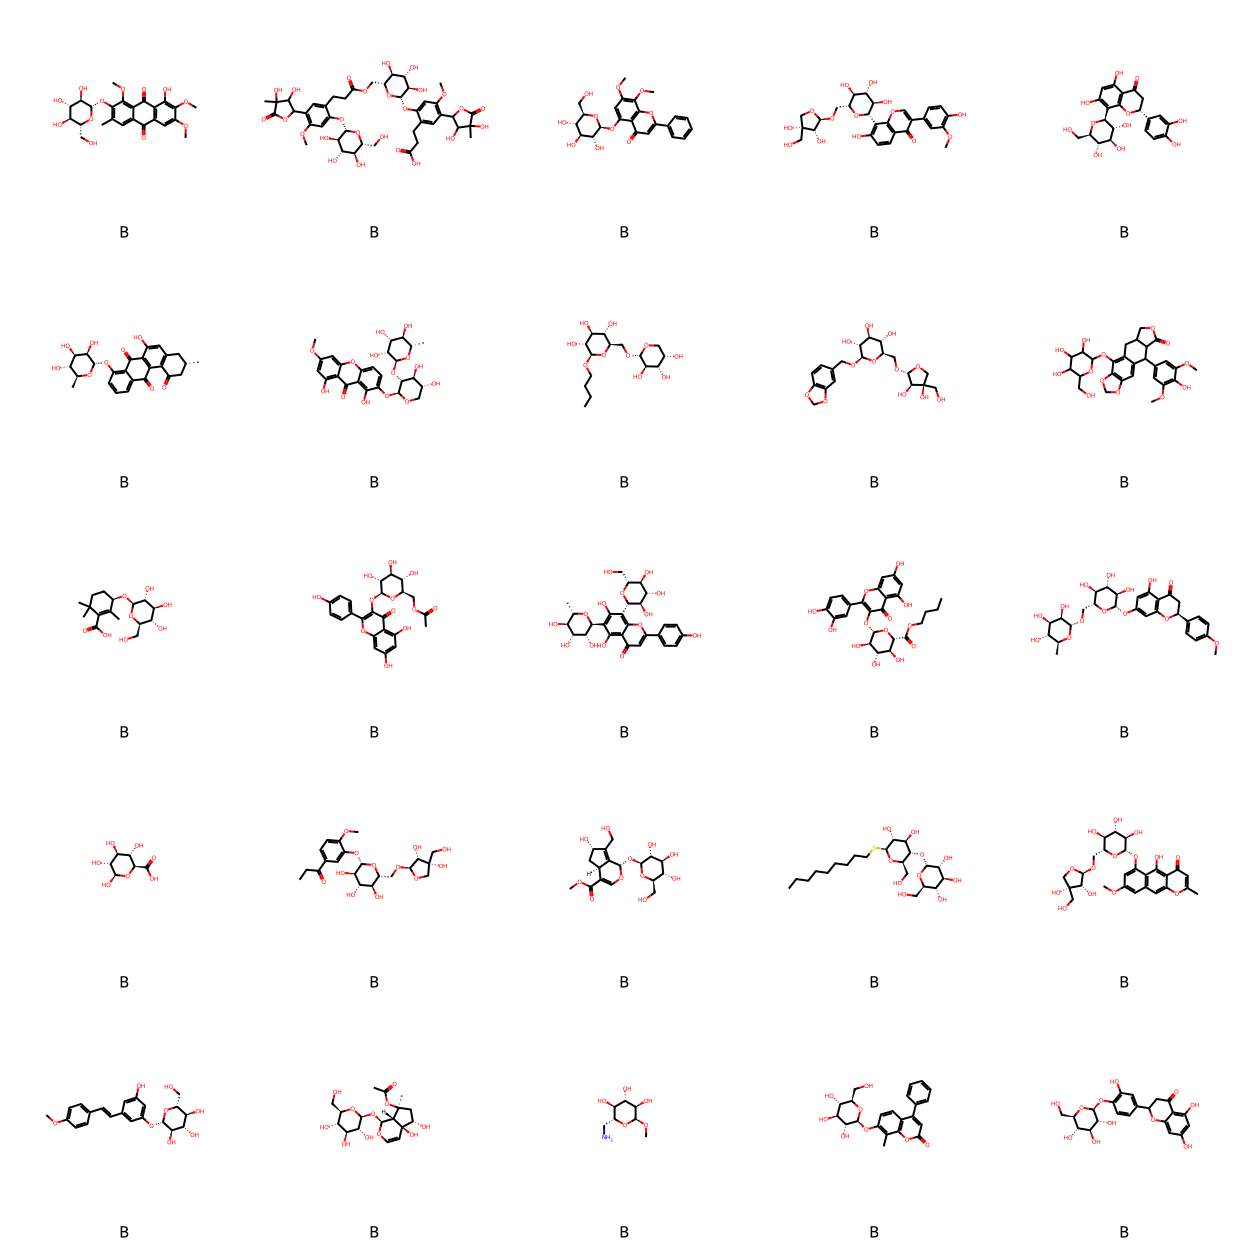

In [11]:
# Visualize exclusive clusters
exclusive_a_views = visualize_exclusive_clusters(
    final_mol_ids=final_mol_ids,
    smiles_dirs=smiles_dirs,
    label='B',
    n_clusters=2,
    max_mols_per_cluster=25,
    cluster_indices=cluster_indices_for_label('B', cluster_flags=cluster_flags)[:2],
)

for entry in exclusive_a_views:
    print(f"Exclusive B cluster index: {entry['cluster_index']} | flag: {entry['flag']}")
    print(f"Counts: {dict(entry['counts'])}")
    display(entry['image'])